# Backblaze drive histories

Explore one downloaded quarter using local file inventory, drive selection, and
Matplotlib SMART waveforms. A full quarter requires several GB of disk space.
Download explicitly in a terminal first:

```bash
uv run --locked python scripts/download.py backblaze --variant 2025-q1
```

This notebook does not initiate downloads. Configure data_root in pdmdata.toml.


In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
import polars as pl
import pdmdata
from pdmdata.backblaze import inventory, verify
from pdmdata.backblaze.viz import plot_waveforms

VARIANT = "2025-q1"
inventory(VARIANT).select("date", "bytes")


Choose a drive from a single day, then load its history. Replace SERIAL with a known drive serial number to reproduce a specific experiment.

In [2]:
files = inventory(VARIANT)
first_day = files["date"].min()
candidates = pdmdata.load("backblaze", variant=VARIANT, start_date=first_day,
                          end_date=first_day, columns=["serial_number", "model"])
SERIAL = candidates.head(1).collect()["serial_number"][0]
history = pdmdata.load("backblaze", variant=VARIANT, serial_number=SERIAL)
history.select("date", "serial_number", "model", "failure").collect()


date,serial_number,model,failure
date,str,str,u8
2025-01-01,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-01-02,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-01-03,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-01-04,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-01-05,"""2207E60CC65A""","""CT250MX500SSD1""",0
…,…,…,…
2025-03-27,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-03-28,"""2207E60CC65A""","""CT250MX500SSD1""",0
2025-03-29,"""2207E60CC65A""","""CT250MX500SSD1""",0


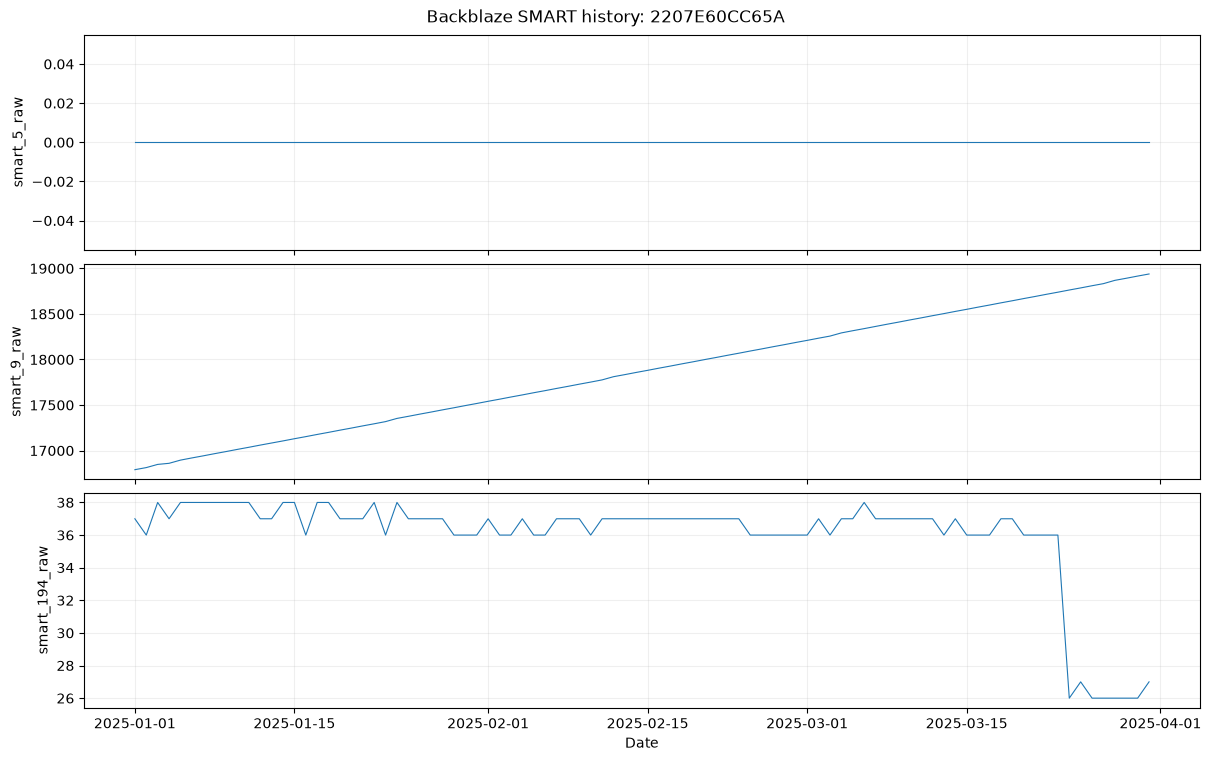

In [3]:
preferred = ["smart_5_raw", "smart_9_raw", "smart_194_raw"]
available = history.collect_schema().names()
columns = [c for c in preferred if c in available]
figure = plot_waveforms(history, serial_number=SERIAL, columns=columns)
plt.show()


## Optional verification

`verify(VARIANT, check_archive=True)` reads the complete quarter and checks
calendar coverage, record validity, and extracted-file integrity against the
local ZIP. It may take time. No network access is used.

SMART availability depends on the drive model. Missing values are not zero.
Reported failure dates are marked in red. Disappearance alone is not a failure
label; define censoring explicitly for survival experiments. Saved Matplotlib
outputs can be displayed on GitHub after running and saving this notebook.
